# Fraudulent Job Posting Detection - New Preprocessing Pipeline


In [83]:
# Import libraries
import pandas as pd
import numpy as np


In [84]:
# Load the dataset
df = pd.read_csv("fake_job_postings 2.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Dataset shape: (17880, 18)
Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [85]:
# Drop job_id column (not useful for prediction)
df = df.drop(columns=['job_id'])
print(f"Shape after dropping job_id: {df.shape}")


Shape after dropping job_id: (17880, 17)


## Step 2: Fill missing values with 'Unknown'


In [86]:
# Check missing values before filling
print("Missing values before filling:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values before filling:
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Total missing: 70106


In [87]:
# Fill all missing values with 'Unknown'
# Note: Only fill object (string) columns, keep numeric columns as-is
object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].fillna('Unknown')

print("Missing values after filling:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values after filling:
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

Total missing: 0


## Step 3: Split Location into Country, State, City


In [88]:
# Function to parse location into country, state, city
def parse_location(loc):
    if pd.isna(loc) or loc == 'Unknown':
        return 'Unknown', 'Unknown', 'Unknown'
    
    parts = [p.strip() for p in str(loc).split(',')]
    
    # Extract country (first part)
    country = parts[0] if len(parts) > 0 and parts[0] else 'Unknown'
    
    # Extract state (second part)
    state = parts[1] if len(parts) > 1 and parts[1] else 'Unknown'
    
    # Extract city (third part onwards, joined back if multiple parts)
    city = ', '.join(parts[2:]) if len(parts) > 2 and parts[2] else 'Unknown'
    
    return country, state, city

# Check if location column exists (in case cell is run multiple times)
if 'location' in df.columns:
    # Apply the function to split location
    df[['country', 'state', 'city']] = df['location'].apply(parse_location).apply(pd.Series)
    
    # Drop the original location column
    df = df.drop(columns=['location'])
    
    print(f"Shape after splitting location: {df.shape}")
    print(f"\nNew columns added: country, state, city")
else:
    print("Location column already processed. Columns exist:")
    print(f"  country: {df['country'].nunique()} unique values")
    print(f"  state: {df['state'].nunique()} unique values")
    print(f"  city: {df['city'].nunique()} unique values")


Shape after splitting location: (17880, 19)

New columns added: country, state, city


In [89]:
# Glimpse of the split location columns
print("--- Sample of Country, State, City columns ---\n")
print(df[['country', 'state', 'city']].head(20).to_string())

print("\n--- Value counts ---")
print(f"\nUnique countries: {df['country'].nunique()}")
print(f"Unique states: {df['state'].nunique()}")
print(f"Unique cities: {df['city'].nunique()}")

print("\n--- Top 10 Countries ---")
print(df['country'].value_counts().head(10))


--- Sample of Country, State, City columns ---

   country    state              city
0       US       NY          New York
1       NZ  Unknown          Auckland
2       US       IA             Wever
3       US       DC        Washington
4       US       FL        Fort Worth
5       US       MD           Unknown
6       DE       BE            Berlin
7       US       CA     San Francisco
8       US       FL         Pensacola
9       US       AZ           Phoenix
10      US       NJ       Jersey City
11      GB      LND            London
12      US       CT          Stamford
13      US       FL           Orlando
14      AU      NSW            Sydney
15      SG       01         Singapore
16      IL  Unknown  Tel Aviv, Israel
17      GB      SOS   Southend-on-Sea
18      US       NY          New York
19      US       PA     USA Northeast

--- Value counts ---

Unique countries: 91
Unique states: 325
Unique cities: 2257

--- Top 10 Countries ---
country
US         10656
GB          2384
GR 

## Step 4: Train/Test Split (Stratified)


In [90]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('fraudulent', axis=1)
y = df['fraudulent']

# Stratified split: maintains same fraud ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # ensures same class distribution in both sets
)

print("="*50)
print("TRAIN/TEST SPLIT COMPLETE")
print("="*50)
print(f"\nTraining set:")
print(f"  Samples: {len(X_train)}")
print(f"  Fraud cases: {y_train.sum()} ({y_train.mean()*100:.2f}%)")

print(f"\nTest set:")
print(f"  Samples: {len(X_test)}")
print(f"  Fraud cases: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

print(f"\nOriginal fraud rate: {y.mean()*100:.2f}%")
print("✓ Stratified split preserved class distribution")


TRAIN/TEST SPLIT COMPLETE

Training set:
  Samples: 14304
  Fraud cases: 693 (4.84%)

Test set:
  Samples: 3576
  Fraud cases: 173 (4.84%)

Original fraud rate: 4.84%
✓ Stratified split preserved class distribution


## Step 5: Categorical Encoding (Target & Frequency Encoding)


### Define Encoder Classes


In [91]:
class TargetEncoder:
    """
    Encodes categorical columns using target mean encoding.
    - fit(): Calculates mean of target for each category (from training data only)
    - transform(): Replaces categories with their target means
    - Unseen categories get the global mean as fallback
    """
    
    def __init__(self, columns, smoothing=1.0):
        """
        Args:
            columns: List of column names to encode
            smoothing: Smoothing factor to blend category mean with global mean
                      Higher values = more regularization for rare categories
        """
        self.columns = columns
        self.smoothing = smoothing
        self.encoding_maps = {}  # {column: {category: encoded_value}}
        self.global_mean = None
        self.category_counts = {}  # for smoothing
        
    def fit(self, X, y):
        """Fit encoder on training data only."""
        self.global_mean = y.mean()
        
        for col in self.columns:
            # Calculate mean target for each category
            stats = pd.DataFrame({
                'mean': y.groupby(X[col]).mean(),
                'count': y.groupby(X[col]).count()
            })
            
            # Apply smoothing: blend category mean with global mean based on count
            # smoothed_mean = (count * category_mean + smoothing * global_mean) / (count + smoothing)
            smoothed = (stats['count'] * stats['mean'] + self.smoothing * self.global_mean) / (stats['count'] + self.smoothing)
            
            self.encoding_maps[col] = smoothed.to_dict()
            self.category_counts[col] = stats['count'].to_dict()
        
        return self
    
    def transform(self, X):
        """Transform data using fitted encoding maps."""
        X_copy = X.copy()
        
        for col in self.columns:
            # Map categories to encoded values, use global_mean for unseen categories
            X_copy[col] = X_copy[col].map(
                lambda x: self.encoding_maps[col].get(x, self.global_mean)
            )
        
        return X_copy
    
    def fit_transform(self, X, y):
        """Fit and transform in one step."""
        return self.fit(X, y).transform(X)
    
    def get_encoding_maps(self):
        """Return encoding maps for saving/deployment."""
        return {
            'encoding_maps': self.encoding_maps,
            'global_mean': self.global_mean,
            'columns': self.columns,
            'smoothing': self.smoothing
        }


class FrequencyEncoder:
    """
    Encodes categorical columns using frequency (count) encoding.
    - fit(): Counts occurrences of each category (from training data only)
    - transform(): Replaces categories with their frequency/count
    - Unseen categories get 0 as fallback (never seen)
    """
    
    def __init__(self, columns, normalize=True):
        """
        Args:
            columns: List of column names to encode
            normalize: If True, use relative frequency (0-1). If False, use raw counts.
        """
        self.columns = columns
        self.normalize = normalize
        self.encoding_maps = {}  # {column: {category: frequency}}
        self.total_counts = {}   # for normalization
        
    def fit(self, X, y=None):
        """Fit encoder on training data only. y is not used but kept for API consistency."""
        for col in self.columns:
            counts = X[col].value_counts()
            
            if self.normalize:
                # Normalize to 0-1 range
                self.encoding_maps[col] = (counts / len(X)).to_dict()
            else:
                self.encoding_maps[col] = counts.to_dict()
            
            self.total_counts[col] = len(X)
        
        return self
    
    def transform(self, X):
        """Transform data using fitted encoding maps."""
        X_copy = X.copy()
        
        for col in self.columns:
            # Map categories to frequencies, use 0 for unseen categories
            X_copy[col] = X_copy[col].map(
                lambda x: self.encoding_maps[col].get(x, 0)
            )
        
        return X_copy
    
    def fit_transform(self, X, y=None):
        """Fit and transform in one step."""
        return self.fit(X, y).transform(X)
    
    def get_encoding_maps(self):
        """Return encoding maps for saving/deployment."""
        return {
            'encoding_maps': self.encoding_maps,
            'columns': self.columns,
            'normalize': self.normalize
        }


print("✓ TargetEncoder class defined")
print("✓ FrequencyEncoder class defined")


✓ TargetEncoder class defined
✓ FrequencyEncoder class defined


### Apply Encoders to Categorical Columns


In [92]:
# Define which columns to encode with which method

# Target Encoding: for medium-high cardinality categorical columns
# These columns have fraud signal that we want to capture
target_encode_cols = ['industry', 'function', 'department', 'country', 'state']

# Frequency Encoding: for very high cardinality columns
# City has too many unique values for target encoding to be stable
freq_encode_cols = ['city']

# Create and fit encoders on TRAINING DATA ONLY
target_encoder = TargetEncoder(columns=target_encode_cols, smoothing=1.0)
freq_encoder = FrequencyEncoder(columns=freq_encode_cols, normalize=True)

# Fit on training data
target_encoder.fit(X_train, y_train)
freq_encoder.fit(X_train)

print("✓ Encoders fitted on training data")
print(f"  Target Encoder: {target_encode_cols}")
print(f"  Frequency Encoder: {freq_encode_cols}")
print(f"  Global fraud mean (fallback): {target_encoder.global_mean:.4f}")


✓ Encoders fitted on training data
  Target Encoder: ['industry', 'function', 'department', 'country', 'state']
  Frequency Encoder: ['city']
  Global fraud mean (fallback): 0.0484


In [93]:
# Transform BOTH training and test data using the fitted encoders

# Apply target encoding
X_train_encoded = target_encoder.transform(X_train)
X_test_encoded = target_encoder.transform(X_test)

# Apply frequency encoding
X_train_encoded = freq_encoder.transform(X_train_encoded)
X_test_encoded = freq_encoder.transform(X_test_encoded)

print("✓ Encoding applied to both train and test data")
print(f"\nTraining data shape: {X_train_encoded.shape}")
print(f"Test data shape: {X_test_encoded.shape}")


✓ Encoding applied to both train and test data

Training data shape: (14304, 18)
Test data shape: (3576, 18)


In [94]:
## Step 6: Title Feature Engineering


In [95]:
import re

class TitleFeatureExtractor:
    """
    Extracts meaningful features from job title text.
    No fitting required - uses rule-based extraction.
    """
    
    def __init__(self):
        # Define keyword patterns
        self.senior_keywords = ['senior', 'sr.', 'sr ', 'lead', 'head', 'director', 
                                'manager', 'chief', 'principal', 'vp', 'vice president']
        self.junior_keywords = ['junior', 'jr.', 'jr ', 'entry', 'intern', 'trainee', 
                                'graduate', 'assistant', 'associate', 'beginner']
        self.remote_keywords = ['remote', 'work from home', 'wfh', 'telecommute', 
                                'virtual', 'home-based', 'home based']
        self.urgent_keywords = ['urgent', 'immediate', 'asap', 'now hiring', 
                                'start immediately', 'hurry', 'limited time']
        self.parttime_keywords = ['part time', 'part-time', 'parttime', 'freelance', 
                                  'contract', 'temporary', 'temp ']
        # Suspicious patterns (common in scam job postings)
        self.suspicious_keywords = ['easy money', 'work from home', 'no experience', 
                                    'unlimited income', 'be your own boss', 'get paid daily']
    
    def _contains_any(self, text, keywords):
        """Check if text contains any of the keywords."""
        text_lower = text.lower()
        return any(kw in text_lower for kw in keywords)
    
    def _count_keywords(self, text, keywords):
        """Count how many keywords appear in text."""
        text_lower = text.lower()
        return sum(1 for kw in keywords if kw in text_lower)
    
    def transform(self, X, title_column='title'):
        """Extract features from title column."""
        X_copy = X.copy()
        titles = X_copy[title_column].fillna('').astype(str)
        
        # Basic text features
        X_copy['title_length'] = titles.str.len()
        X_copy['title_word_count'] = titles.str.split().str.len()
        
        # Keyword presence features (binary)
        X_copy['title_has_senior'] = titles.apply(
            lambda x: 1 if self._contains_any(x, self.senior_keywords) else 0
        )
        X_copy['title_has_junior'] = titles.apply(
            lambda x: 1 if self._contains_any(x, self.junior_keywords) else 0
        )
        X_copy['title_has_remote'] = titles.apply(
            lambda x: 1 if self._contains_any(x, self.remote_keywords) else 0
        )
        X_copy['title_has_urgent'] = titles.apply(
            lambda x: 1 if self._contains_any(x, self.urgent_keywords) else 0
        )
        X_copy['title_has_parttime'] = titles.apply(
            lambda x: 1 if self._contains_any(x, self.parttime_keywords) else 0
        )
        X_copy['title_has_suspicious'] = titles.apply(
            lambda x: 1 if self._contains_any(x, self.suspicious_keywords) else 0
        )
        
        # Text quality features
        X_copy['title_capital_ratio'] = titles.apply(
            lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
        )
        X_copy['title_special_char_ratio'] = titles.apply(
            lambda x: sum(1 for c in x if not c.isalnum() and c != ' ') / max(len(x), 1)
        )
        X_copy['title_digit_count'] = titles.apply(
            lambda x: sum(1 for c in x if c.isdigit())
        )
        
        # Drop original title column
        X_copy = X_copy.drop(columns=[title_column])
        
        return X_copy
    
    def get_feature_names(self):
        """Return list of features created."""
        return [
            'title_length', 'title_word_count',
            'title_has_senior', 'title_has_junior', 'title_has_remote',
            'title_has_urgent', 'title_has_parttime', 'title_has_suspicious',
            'title_capital_ratio', 'title_special_char_ratio', 'title_digit_count'
        ]

print("✓ TitleFeatureExtractor class defined")
print(f"  Features to extract: {TitleFeatureExtractor().get_feature_names()}")


✓ TitleFeatureExtractor class defined
  Features to extract: ['title_length', 'title_word_count', 'title_has_senior', 'title_has_junior', 'title_has_remote', 'title_has_urgent', 'title_has_parttime', 'title_has_suspicious', 'title_capital_ratio', 'title_special_char_ratio', 'title_digit_count']


In [96]:
# Apply title feature extraction to both train and test

title_extractor = TitleFeatureExtractor()

# Extract features (this also drops the original 'title' column)
X_train_encoded = title_extractor.transform(X_train_encoded)
X_test_encoded = title_extractor.transform(X_test_encoded)

print("✓ Title features extracted")
print(f"\nTraining data shape: {X_train_encoded.shape}")
print(f"Test data shape: {X_test_encoded.shape}")
print(f"\nNew title features added: {title_extractor.get_feature_names()}")


✓ Title features extracted

Training data shape: (14304, 28)
Test data shape: (3576, 28)

New title features added: ['title_length', 'title_word_count', 'title_has_senior', 'title_has_junior', 'title_has_remote', 'title_has_urgent', 'title_has_parttime', 'title_has_suspicious', 'title_capital_ratio', 'title_special_char_ratio', 'title_digit_count']


In [97]:
# Verify title features

print("="*60)
print("TITLE FEATURE VERIFICATION")
print("="*60)

# Create instance if not exists (for standalone cell execution)
if 'title_extractor' not in dir():
    title_extractor = TitleFeatureExtractor()

title_features = title_extractor.get_feature_names()
print("\n--- Sample of Title Features (Training) ---")
print(X_train_encoded[title_features].head(10).to_string())

print("\n--- Title Feature Statistics ---")
print(X_train_encoded[title_features].describe().round(3).to_string())

# Check fraud correlation with title features
print("\n--- Title Features Correlation with Fraud ---")
train_with_y = X_train_encoded.copy()
train_with_y['fraudulent'] = y_train
for feat in title_features:
    corr = train_with_y[feat].corr(train_with_y['fraudulent'])
    print(f"  {feat}: {corr:.4f}")


TITLE FEATURE VERIFICATION

--- Sample of Title Features (Training) ---
       title_length  title_word_count  title_has_senior  title_has_junior  title_has_remote  title_has_urgent  title_has_parttime  title_has_suspicious  title_capital_ratio  title_special_char_ratio  title_digit_count
7530             30                 3                 0                 0                 0                 0                   0                     0             0.100000                  0.000000                  0
129              27                 3                 0                 1                 0                 0                   0                     0             0.111111                  0.000000                  0
4640             22                 3                 0                 0                 0                 0                   0                     0             0.136364                  0.000000                  0
402              31                 3                 0 

## Save Current Progress


In [98]:
# Save encoding maps for deployment (to use with frontend)
import pickle

encoding_artifacts = {
    'target_encoder': target_encoder.get_encoding_maps(),
    'freq_encoder': freq_encoder.get_encoding_maps(),
    'title_features': title_extractor.get_feature_names()  # Include title feature names
}

with open('encoding_maps.pkl', 'wb') as f:
    pickle.dump(encoding_artifacts, f)

print("✓ Encoding maps saved to: encoding_maps.pkl")
print("\nThis file contains:")
print("  - Target encoding maps for:", target_encode_cols)
print("  - Frequency encoding maps for:", freq_encode_cols)
print("  - Title feature names:", len(title_extractor.get_feature_names()), "features")
print("  - Global mean fallback:", target_encoder.global_mean)


✓ Encoding maps saved to: encoding_maps.pkl

This file contains:
  - Target encoding maps for: ['industry', 'function', 'department', 'country', 'state']
  - Frequency encoding maps for: ['city']
  - Title feature names: 11 features
  - Global mean fallback: 0.04844798657718121


In [99]:
# Save encoded datasets
X_train_encoded.to_excel("X_train_encoded.xlsx", index=False)
X_test_encoded.to_excel("X_test_encoded.xlsx", index=False)

# Also save with target column for reference
train_encoded_with_y = X_train_encoded.copy()
train_encoded_with_y['fraudulent'] = y_train

test_encoded_with_y = X_test_encoded.copy()
test_encoded_with_y['fraudulent'] = y_test

train_encoded_with_y.to_excel("train_encoded_full.xlsx", index=False)
test_encoded_with_y.to_excel("test_encoded_full.xlsx", index=False)

print("✓ Files saved:")
print(f"  - X_train_encoded.xlsx ({X_train_encoded.shape})")
print(f"  - X_test_encoded.xlsx ({X_test_encoded.shape})")
print(f"  - train_encoded_full.xlsx (with target)")
print(f"  - test_encoded_full.xlsx (with target)")
print(f"  - encoding_maps.pkl (for deployment)")

print(f"\n--- Final Column List ({len(X_train_encoded.columns)} columns) ---")
print(list(X_train_encoded.columns))


✓ Files saved:
  - X_train_encoded.xlsx ((14304, 28))
  - X_test_encoded.xlsx ((3576, 28))
  - train_encoded_full.xlsx (with target)
  - test_encoded_full.xlsx (with target)
  - encoding_maps.pkl (for deployment)

--- Final Column List (28 columns) ---
['department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'country', 'state', 'city', 'title_length', 'title_word_count', 'title_has_senior', 'title_has_junior', 'title_has_remote', 'title_has_urgent', 'title_has_parttime', 'title_has_suspicious', 'title_capital_ratio', 'title_special_char_ratio', 'title_digit_count']


## Text Vectorization (TF-IDF)


In [100]:
# Function to combine text columns

def combine_text_columns(df, text_columns=['company_profile', 'description', 'requirements', 'benefits']):
    """
    Combines multiple text columns into a single text column.
    Handles missing values by replacing with empty string.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe containing text columns
    text_columns : list
        List of column names to combine
    
    Returns:
    --------
    Series
        Combined text as a pandas Series
    """
    combined = df[text_columns[0]].fillna('').astype(str)
    
    for col in text_columns[1:]:
        combined = combined + ' ' + df[col].fillna('').astype(str)
    
    # Clean up extra whitespace
    combined = combined.str.strip()
    combined = combined.str.replace(r'\s+', ' ', regex=True)
    
    return combined

# Test the function
print("✓ combine_text_columns() function defined")
print(f"\nText columns to combine: {['company_profile', 'description', 'requirements', 'benefits']}")


✓ combine_text_columns() function defined

Text columns to combine: ['company_profile', 'description', 'requirements', 'benefits']


In [101]:
# TF-IDF Vectorizer wrapper class
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

class TextVectorizer:
    """
    Wrapper class for TF-IDF vectorization.
    Provides methods to fit, transform, and get feature names.
    """
    
    def __init__(self, max_features=50, ngram_range=(1, 2), min_df=5, max_df=0.90):
        """
        Initialize the TF-IDF vectorizer.
        
        Parameters:
        -----------
        max_features : int
            Maximum number of features (vocabulary size)
        ngram_range : tuple
            Range of n-grams to extract (1,2) = unigrams + bigrams
        min_df : int
            Minimum document frequency (ignore terms in fewer docs)
        max_df : float
            Maximum document frequency (ignore terms in more than X% of docs)
        """
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=max_df,
            stop_words='english',
            lowercase=True,
            strip_accents='unicode'
        )
        self.feature_names = None
        self.is_fitted = False
    
    def fit(self, text_series):
        """
        Fit the vectorizer on training text data.
        
        Parameters:
        -----------
        text_series : Series
            Pandas Series containing text data
        """
        self.vectorizer.fit(text_series)
        self.feature_names = [f"tfidf_{name}" for name in self.vectorizer.get_feature_names_out()]
        self.is_fitted = True
        return self
    
    def transform(self, text_series):
        """
        Transform text data to TF-IDF features.
        
        Parameters:
        -----------
        text_series : Series
            Pandas Series containing text data
            
        Returns:
        --------
        DataFrame
            DataFrame with TF-IDF features
        """
        if not self.is_fitted:
            raise ValueError("Vectorizer not fitted. Call fit() first.")
        
        tfidf_matrix = self.vectorizer.transform(text_series)
        
        # Convert sparse matrix to DataFrame
        tfidf_df = pd.DataFrame(
            tfidf_matrix.toarray(),
            columns=self.feature_names,
            index=text_series.index
        )
        
        return tfidf_df
    
    def fit_transform(self, text_series):
        """Fit and transform in one step."""
        self.fit(text_series)
        return self.transform(text_series)
    
    def get_feature_names(self):
        """Return list of feature names."""
        return self.feature_names
    
    def get_top_features(self, n=20):
        """Return top N features by IDF score."""
        if not self.is_fitted:
            raise ValueError("Vectorizer not fitted. Call fit() first.")
        
        idf_scores = self.vectorizer.idf_
        feature_names = self.vectorizer.get_feature_names_out()
        
        # Sort by IDF (higher = rarer/more important)
        sorted_idx = idf_scores.argsort()[::-1][:n]
        
        return [(feature_names[i], idf_scores[i]) for i in sorted_idx]

print("✓ TextVectorizer class defined")
print(f"\nDefault settings:")
print(f"  - max_features: 50")
print(f"  - ngram_range: (1, 2) = words + 2-word phrases")
print(f"  - min_df: 5 (must appear in 5+ documents)")
print(f"  - max_df: 0.90 (skip if in 90%+ documents)")


✓ TextVectorizer class defined

Default settings:
  - max_features: 50
  - ngram_range: (1, 2) = words + 2-word phrases
  - min_df: 5 (must appear in 5+ documents)
  - max_df: 0.90 (skip if in 90%+ documents)


In [102]:
# Apply text combination and TF-IDF vectorization

# Define text columns to combine
text_columns = ['company_profile', 'description', 'requirements', 'benefits']

# Step 1: Combine text columns
print("Step 1: Combining text columns...")
train_combined_text = combine_text_columns(X_train_encoded, text_columns)
test_combined_text = combine_text_columns(X_test_encoded, text_columns)

print(f"  Training text samples: {len(train_combined_text)}")
print(f"  Test text samples: {len(test_combined_text)}")
print(f"\n  Sample combined text (first 200 chars):")
print(f"  '{train_combined_text.iloc[0][:200]}...'")

# Step 2: Fit TF-IDF on training data only
print("\nStep 2: Fitting TF-IDF vectorizer on training data...")
text_vectorizer = TextVectorizer(max_features=50, ngram_range=(1, 2), min_df=5, max_df=0.90)
text_vectorizer.fit(train_combined_text)

print(f"  Vocabulary size: {len(text_vectorizer.get_feature_names())} features")

# Step 3: Transform both train and test
print("\nStep 3: Transforming text to TF-IDF features...")
train_tfidf = text_vectorizer.transform(train_combined_text)
test_tfidf = text_vectorizer.transform(test_combined_text)

print(f"  Training TF-IDF shape: {train_tfidf.shape}")
print(f"  Test TF-IDF shape: {test_tfidf.shape}")

# Show top features by IDF score
print("\n--- Top 20 TF-IDF Features (by rarity/importance) ---")
for feature, idf in text_vectorizer.get_top_features(20):
    print(f"  {feature:<30} IDF: {idf:.3f}")


Step 1: Combining text columns...
  Training text samples: 14304
  Test text samples: 3576

  Sample combined text (first 200 chars):
  'Tidewater Finance Co. was established in 1992 for the initial purpose of purchasing, and servicing retail installment contracts. There are two divisions: Tidewater Credit Services, providing indirect ...'

Step 2: Fitting TF-IDF vectorizer on training data...
  Vocabulary size: 50 features

Step 3: Transforming text to TF-IDF features...
  Training TF-IDF shape: (14304, 50)
  Test TF-IDF shape: (3576, 50)

--- Top 20 TF-IDF Features (by rarity/importance) ---
  marketing                      IDF: 2.529
  sales                          IDF: 2.450
  technical                      IDF: 2.440
  data                           IDF: 2.423
  web                            IDF: 2.419
  products                       IDF: 2.393
  client                         IDF: 2.386
  software                       IDF: 2.341
  product                        IDF: 2.321
  d

In [103]:
# Merge TF-IDF features with encoded data and drop original text columns

# Drop original text columns (they're now represented by TF-IDF features)
X_train_final = X_train_encoded.drop(columns=text_columns)
X_test_final = X_test_encoded.drop(columns=text_columns)

# Reset indices to ensure proper alignment
X_train_final = X_train_final.reset_index(drop=True)
X_test_final = X_test_final.reset_index(drop=True)
train_tfidf = train_tfidf.reset_index(drop=True)
test_tfidf = test_tfidf.reset_index(drop=True)

# Concatenate TF-IDF features
X_train_final = pd.concat([X_train_final, train_tfidf], axis=1)
X_test_final = pd.concat([X_test_final, test_tfidf], axis=1)

print("✓ TF-IDF features merged with encoded data")
print(f"\n--- Final Dataset Shape ---")
print(f"  Training: {X_train_final.shape}")
print(f"  Test: {X_test_final.shape}")

print(f"\n--- Column Breakdown ---")
tfidf_cols = [c for c in X_train_final.columns if c.startswith('tfidf_')]
other_cols = [c for c in X_train_final.columns if not c.startswith('tfidf_')]
print(f"  Non-TF-IDF features: {len(other_cols)}")
print(f"  TF-IDF features: {len(tfidf_cols)}")
print(f"  Total features: {len(X_train_final.columns)}")

print(f"\n--- All Columns ({len(X_train_final.columns)}) ---")
print(list(X_train_final.columns))


✓ TF-IDF features merged with encoded data

--- Final Dataset Shape ---
  Training: (14304, 74)
  Test: (3576, 74)

--- Column Breakdown ---
  Non-TF-IDF features: 24
  TF-IDF features: 50
  Total features: 74

--- All Columns (74) ---
['department', 'salary_range', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'country', 'state', 'city', 'title_length', 'title_word_count', 'title_has_senior', 'title_has_junior', 'title_has_remote', 'title_has_urgent', 'title_has_parttime', 'title_has_suspicious', 'title_capital_ratio', 'title_special_char_ratio', 'title_digit_count', 'tfidf_ability', 'tfidf_amp', 'tfidf_based', 'tfidf_best', 'tfidf_business', 'tfidf_client', 'tfidf_clients', 'tfidf_communication', 'tfidf_company', 'tfidf_customer', 'tfidf_customers', 'tfidf_data', 'tfidf_design', 'tfidf_development', 'tfidf_environment', 'tfidf_experience', 'tfidf_help', 'tfidf_high', 'tfidf_including', 'tf

In [104]:
# Verify TF-IDF features and check correlation with fraud

print("="*60)
print("TF-IDF FEATURE VERIFICATION")
print("="*60)

# Get TF-IDF column names
tfidf_cols = [c for c in X_train_final.columns if c.startswith('tfidf_')]

print(f"\n--- TF-IDF Feature Statistics ---")
print(X_train_final[tfidf_cols].describe().round(4).to_string())

# Check fraud correlation with TF-IDF features
print(f"\n--- TF-IDF Features Correlation with Fraud ---")
train_with_y = X_train_final.copy()
train_with_y['fraudulent'] = y_train.reset_index(drop=True)

correlations = []
for col in tfidf_cols:
    corr = train_with_y[col].corr(train_with_y['fraudulent'])
    correlations.append((col, corr))

# Sort by absolute correlation
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nTop 15 TF-IDF features by correlation with fraud:")
for feat, corr in correlations[:15]:
    direction = "🚩 fraud signal" if corr > 0.02 else ("✓ legit signal" if corr < -0.02 else "neutral")
    print(f"  {feat:<35} corr: {corr:+.4f}  {direction}")


TF-IDF FEATURE VERIFICATION

--- TF-IDF Feature Statistics ---
       tfidf_ability   tfidf_amp  tfidf_based  tfidf_best  tfidf_business  tfidf_client  tfidf_clients  tfidf_communication  tfidf_company  tfidf_customer  tfidf_customers  tfidf_data  tfidf_design  tfidf_development  tfidf_environment  tfidf_experience  tfidf_help  tfidf_high  tfidf_including   tfidf_job  tfidf_knowledge  tfidf_looking  tfidf_management  tfidf_marketing   tfidf_new  tfidf_people  tfidf_position  tfidf_product  tfidf_products  tfidf_provide  tfidf_quality  tfidf_required  tfidf_sales  tfidf_service  tfidf_services  tfidf_skills  tfidf_software  tfidf_solutions  tfidf_strong  tfidf_support  tfidf_team  tfidf_technical  tfidf_technology  tfidf_time  tfidf_unknown   tfidf_web  tfidf_work  tfidf_working  tfidf_world  tfidf_years
count     14304.0000  14304.0000   14304.0000  14304.0000      14304.0000    14304.0000     14304.0000           14304.0000     14304.0000      14304.0000       14304.0000  14304.0000  

In [105]:
# Save the TF-IDF vectorizer for deployment
import pickle

# Save the vectorizer object itself (needed to transform new inputs)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(text_vectorizer.vectorizer, f)

print("✓ TF-IDF vectorizer saved to: tfidf_vectorizer.pkl")

# Update encoding maps to include TF-IDF info
encoding_artifacts = {
    'target_encoder': target_encoder.get_encoding_maps(),
    'freq_encoder': freq_encoder.get_encoding_maps(),
    'title_features': title_extractor.get_feature_names(),
    'tfidf_features': text_vectorizer.get_feature_names(),
    'text_columns': text_columns,  # Which columns to combine
    'global_mean': target_encoder.global_mean
}

with open('encoding_maps.pkl', 'wb') as f:
    pickle.dump(encoding_artifacts, f)

print("✓ Updated encoding_maps.pkl with TF-IDF info")
print("\nSaved artifacts for deployment:")
print(f"  - tfidf_vectorizer.pkl (the fitted vectorizer)")
print(f"  - encoding_maps.pkl (all encoding info)")
print(f"  - TF-IDF feature count: {len(text_vectorizer.get_feature_names())}")


✓ TF-IDF vectorizer saved to: tfidf_vectorizer.pkl
✓ Updated encoding_maps.pkl with TF-IDF info

Saved artifacts for deployment:
  - tfidf_vectorizer.pkl (the fitted vectorizer)
  - encoding_maps.pkl (all encoding info)
  - TF-IDF feature count: 50


In [106]:
# Save final preprocessed datasets

# Save feature matrices
X_train_final.to_excel("X_train_final.xlsx", index=False)
X_test_final.to_excel("X_test_final.xlsx", index=False)

# Save with target column for reference
train_final_with_y = X_train_final.copy()
train_final_with_y['fraudulent'] = y_train.reset_index(drop=True)

test_final_with_y = X_test_final.copy()
test_final_with_y['fraudulent'] = y_test.reset_index(drop=True)

train_final_with_y.to_excel("train_final_full.xlsx", index=False)
test_final_with_y.to_excel("test_final_full.xlsx", index=False)

print("="*60)
print("FINAL PREPROCESSED DATA SAVED")
print("="*60)

print(f"\n✓ Files saved:")
print(f"  - X_train_final.xlsx ({X_train_final.shape})")
print(f"  - X_test_final.xlsx ({X_test_final.shape})")
print(f"  - train_final_full.xlsx (with target)")
print(f"  - test_final_full.xlsx (with target)")

print(f"\n--- Final Feature Summary ---")
print(f"  Categorical (encoded): {len([c for c in X_train_final.columns if c in ['department', 'salary_range', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'country', 'state', 'city']])}")
print(f"  Binary features: {len([c for c in X_train_final.columns if c in ['telecommuting', 'has_company_logo', 'has_questions']])}")
print(f"  Title features: {len([c for c in X_train_final.columns if c.startswith('title_')])}")
print(f"  TF-IDF features: {len([c for c in X_train_final.columns if c.startswith('tfidf_')])}")
print(f"  -" * 20)
print(f"  TOTAL: {len(X_train_final.columns)} features")

print("\n✅ Preprocessing complete! Ready for model training.")


FINAL PREPROCESSED DATA SAVED

✓ Files saved:
  - X_train_final.xlsx ((14304, 74))
  - X_test_final.xlsx ((3576, 74))
  - train_final_full.xlsx (with target)
  - test_final_full.xlsx (with target)

--- Final Feature Summary ---
  Categorical (encoded): 10
  Binary features: 3
  Title features: 11
  TF-IDF features: 50
  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -  -
  TOTAL: 74 features

✅ Preprocessing complete! Ready for model training.


## Ordinal Encoding for Remaining Categorical Columns


In [107]:
# Define ordinal encoding mappings

# Required Experience: Unknown/Not Applicable = 0, then increasing experience
experience_mapping = {
    'Unknown': 0,
    'Not Applicable': 0,
    'Internship': 1,
    'Entry level': 2,
    'Associate': 3,
    'Mid-Senior level': 4,
    'Director': 5,
    'Executive': 6
}

# Required Education: Unknown/Unspecified = 0, then increasing education level
education_mapping = {
    'Unknown': 0,
    'Unspecified': 0,
    'Some High School Coursework': 1,
    'High School or equivalent': 2,
    'Vocational': 3,
    'Vocational - HS Diploma': 3,
    'Some College Coursework Completed': 4,
    'Vocational - Degree': 5,
    'Certification': 5,
    'Associate Degree': 6,
    "Bachelor's Degree": 7,
    'Professional': 8,
    "Master's Degree": 9,
    'Doctorate': 10
}

print("✓ Ordinal mappings defined")
print(f"\nExperience levels: 0-6 (0 = Unknown/NA, 6 = Executive)")
print(f"Education levels: 0-10 (0 = Unknown/Unspecified, 10 = Doctorate)")


✓ Ordinal mappings defined

Experience levels: 0-6 (0 = Unknown/NA, 6 = Executive)
Education levels: 0-10 (0 = Unknown/Unspecified, 10 = Doctorate)


In [108]:
# Apply ordinal encoding to required_experience and required_education

# Apply to training data
X_train_final['required_experience'] = X_train_final['required_experience'].map(experience_mapping)
X_train_final['required_education'] = X_train_final['required_education'].map(education_mapping)

# Apply to test data
X_test_final['required_experience'] = X_test_final['required_experience'].map(experience_mapping)
X_test_final['required_education'] = X_test_final['required_education'].map(education_mapping)

# Check for any unmapped values (NaN after mapping)
train_exp_na = X_train_final['required_experience'].isna().sum()
train_edu_na = X_train_final['required_education'].isna().sum()
test_exp_na = X_test_final['required_experience'].isna().sum()
test_edu_na = X_test_final['required_education'].isna().sum()

print("✓ Ordinal encoding applied")
print(f"\n--- Encoding Results ---")
print(f"Training - required_experience NaN: {train_exp_na}")
print(f"Training - required_education NaN: {train_edu_na}")
print(f"Test - required_experience NaN: {test_exp_na}")
print(f"Test - required_education NaN: {test_edu_na}")

# Show distribution
print(f"\n--- Experience Distribution (Training) ---")
print(X_train_final['required_experience'].value_counts().sort_index())

print(f"\n--- Education Distribution (Training) ---")
print(X_train_final['required_education'].value_counts().sort_index())


✓ Ordinal encoding applied

--- Encoding Results ---
Training - required_experience NaN: 0
Training - required_education NaN: 0
Test - required_experience NaN: 0
Test - required_education NaN: 0

--- Experience Distribution (Training) ---
required_experience
0    6559
1     301
2    2177
3    1832
4    3011
5     314
6     110
Name: count, dtype: int64

--- Education Distribution (Training) ---
required_education
0     7594
1       24
2     1650
3       46
4       78
5      153
6      227
7     4116
8       57
9      339
10      20
Name: count, dtype: int64


In [109]:
# Handle remaining categorical columns: employment_type and salary_range
# Using target encoding (same approach as industry, country, etc.)

print("="*60)
print("ENCODING REMAINING COLUMNS")
print("="*60)

# Check current unique values
print(f"\nemployment_type unique values: {X_train_final['employment_type'].nunique()}")
print(X_train_final['employment_type'].value_counts())

print(f"\nsalary_range unique values: {X_train_final['salary_range'].nunique()}")
print(X_train_final['salary_range'].value_counts().head(10))


ENCODING REMAINING COLUMNS

employment_type unique values: 6
employment_type
Full-time    9306
Unknown      2757
Contract     1224
Part-time     626
Temporary     200
Other         191
Name: count, dtype: int64

salary_range unique values: 772
salary_range
Unknown         12021
0-0               115
40000-50000        42
30000-40000        42
45000-67000        31
80000-100000       28
25000-30000        24
30000-35000        24
30000-50000        24
60000-80000        23
Name: count, dtype: int64


In [110]:
# Apply target encoding to employment_type and salary_range
# Reusing the TargetEncoder class we defined earlier

# Define columns to encode
remaining_cols = ['employment_type', 'salary_range']

# Create new target encoder (columns must be first argument)
remaining_encoder = TargetEncoder(columns=remaining_cols, smoothing=10)

# Fit on training data
remaining_encoder.fit(X_train_final[remaining_cols], y_train.reset_index(drop=True))

# Transform both datasets
X_train_final[remaining_cols] = remaining_encoder.transform(X_train_final[remaining_cols])
X_test_final[remaining_cols] = remaining_encoder.transform(X_test_final[remaining_cols])

print("✓ Target encoding applied to employment_type and salary_range")
print(f"\n--- employment_type after encoding ---")
print(f"Sample values: {X_train_final['employment_type'].head(10).tolist()}")
print(f"Range: {X_train_final['employment_type'].min():.4f} to {X_train_final['employment_type'].max():.4f}")

print(f"\n--- salary_range after encoding ---")
print(f"Sample values: {X_train_final['salary_range'].head(10).tolist()}")
print(f"Range: {X_train_final['salary_range'].min():.4f} to {X_train_final['salary_range'].max():.4f}")


✓ Target encoding applied to employment_type and salary_range

--- employment_type after encoding ---
Sample values: [0.04084204378121208, 0.04084204378121208, 0.04084204378121208, 0.04084204378121208, 0.04084204378121208, 0.04084204378121208, 0.04084204378121208, 0.0713713335257578, 0.04084204378121208, 0.04084204378121208]
Range: 0.0118 to 0.0967

--- salary_range after encoding ---
Sample values: [0.04292947218566801, 0.04292947218566801, 0.04292947218566801, 0.04292947218566801, 0.04292947218566801, 0.04404362416107383, 0.04292947218566801, 0.04292947218566801, 0.04404362416107383, 0.04292947218566801]
Range: 0.0118 to 0.5242


In [111]:
# Verify ALL columns are now numeric

print("="*60)
print("FINAL DATA TYPE VERIFICATION")
print("="*60)

numeric_cols = X_train_final.select_dtypes(include=['number']).columns.tolist()
non_numeric_cols = X_train_final.select_dtypes(exclude=['number']).columns.tolist()

print(f"\n✓ Numeric columns: {len(numeric_cols)}")
print(f"❌ Non-numeric columns: {len(non_numeric_cols)}")

if non_numeric_cols:
    print(f"\n⚠️ Still need encoding: {non_numeric_cols}")
else:
    print("\n✅ ALL COLUMNS ARE NUMERIC!")
    print("\n--- Column Types Summary ---")
    print(X_train_final.dtypes.value_counts())
    
print(f"\n--- Final Shape ---")
print(f"Training: {X_train_final.shape}")
print(f"Test: {X_test_final.shape}")


FINAL DATA TYPE VERIFICATION

✓ Numeric columns: 74
❌ Non-numeric columns: 0

✅ ALL COLUMNS ARE NUMERIC!

--- Column Types Summary ---
float64    60
int64      14
Name: count, dtype: int64

--- Final Shape ---
Training: (14304, 74)
Test: (3576, 74)


In [112]:
# Save final datasets and all encoding artifacts

import pickle

# Update encoding maps with ordinal mappings
encoding_artifacts = {
    'target_encoder': target_encoder.get_encoding_maps(),
    'freq_encoder': freq_encoder.get_encoding_maps(),
    'remaining_encoder': remaining_encoder.get_encoding_maps(),  # employment_type, salary_range
    'experience_mapping': experience_mapping,
    'education_mapping': education_mapping,
    'title_features': title_extractor.get_feature_names(),
    'tfidf_features': text_vectorizer.get_feature_names(),
    'text_columns': text_columns,
    'global_mean': target_encoder.global_mean
}

with open('encoding_maps.pkl', 'wb') as f:
    pickle.dump(encoding_artifacts, f)

# Save final datasets
X_train_final.to_excel("X_train_final.xlsx", index=False)
X_test_final.to_excel("X_test_final.xlsx", index=False)

# Save with target
train_final_with_y = X_train_final.copy()
train_final_with_y['fraudulent'] = y_train.reset_index(drop=True)
test_final_with_y = X_test_final.copy()
test_final_with_y['fraudulent'] = y_test.reset_index(drop=True)

train_final_with_y.to_excel("train_final_full.xlsx", index=False)
test_final_with_y.to_excel("test_final_full.xlsx", index=False)

print("="*60)
print("ALL PREPROCESSING COMPLETE!")
print("="*60)

print(f"\n✓ Files saved:")
print(f"  - X_train_final.xlsx ({X_train_final.shape})")
print(f"  - X_test_final.xlsx ({X_test_final.shape})")
print(f"  - train_final_full.xlsx (with target)")
print(f"  - test_final_full.xlsx (with target)")
print(f"  - encoding_maps.pkl (all encoders)")
print(f"  - tfidf_vectorizer.pkl (TF-IDF vectorizer)")

print(f"\n--- Final Feature Count: {len(X_train_final.columns)} ---")
print(f"\n✅ Dataset ready for model training!")


ALL PREPROCESSING COMPLETE!

✓ Files saved:
  - X_train_final.xlsx ((14304, 74))
  - X_test_final.xlsx ((3576, 74))
  - train_final_full.xlsx (with target)
  - test_final_full.xlsx (with target)
  - encoding_maps.pkl (all encoders)
  - tfidf_vectorizer.pkl (TF-IDF vectorizer)

--- Final Feature Count: 74 ---

✅ Dataset ready for model training!


## Complete Preprocessing Pipeline

Creating a single sklearn Pipeline that performs all transformations in one go.


In [113]:
# Import required libraries for Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import re

print("✓ Libraries imported for Pipeline")


✓ Libraries imported for Pipeline


In [114]:
# Step 1: Drop job_id and fill missing values
class DropAndFillMissing(BaseEstimator, TransformerMixin):
    """Drops job_id column and fills missing values with 'Unknown'."""
    
    def __init__(self, drop_cols=['job_id'], fill_value='Unknown'):
        self.drop_cols = drop_cols
        self.fill_value = fill_value
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        # Drop columns
        for col in self.drop_cols:
            if col in X_copy.columns:
                X_copy = X_copy.drop(columns=[col])
        # Fill missing for object columns
        for col in X_copy.select_dtypes(include=['object']).columns:
            X_copy[col] = X_copy[col].fillna(self.fill_value)
        return X_copy

print("✓ DropAndFillMissing transformer defined")


✓ DropAndFillMissing transformer defined


In [115]:
# Step 2: Split location into country, state, city
class LocationSplitter(BaseEstimator, TransformerMixin):
    """Splits location column into country, state, city."""
    
    def __init__(self, location_col='location'):
        self.location_col = location_col
    
    def fit(self, X, y=None):
        return self
    
    def _parse_location(self, loc):
        """Parse location string into (country, state, city)."""
        if pd.isna(loc) or loc == 'Unknown' or loc.strip() == '':
            return 'Unknown', 'Unknown', 'Unknown'
        
        parts = [p.strip() for p in str(loc).split(',')]
        
        if len(parts) == 1:
            return parts[0], 'Unknown', 'Unknown'
        elif len(parts) == 2:
            return parts[1], parts[0], 'Unknown'
        else:
            return parts[-1], parts[-2], ', '.join(parts[:-2])
    
    def transform(self, X):
        X_copy = X.copy()
        if self.location_col in X_copy.columns:
            parsed = X_copy[self.location_col].apply(self._parse_location)
            X_copy['country'] = parsed.apply(lambda x: x[0])
            X_copy['state'] = parsed.apply(lambda x: x[1])
            X_copy['city'] = parsed.apply(lambda x: x[2])
            X_copy = X_copy.drop(columns=[self.location_col])
        return X_copy

print("✓ LocationSplitter transformer defined")


✓ LocationSplitter transformer defined


In [116]:
# Step 3: Title Feature Extractor
class TitleFeatureTransformer(BaseEstimator, TransformerMixin):
    """Extracts features from title column."""
    
    def __init__(self, title_col='title'):
        self.title_col = title_col
        self.senior_keywords = ['senior', 'sr.', 'sr ', 'lead', 'head', 'director', 
                                'manager', 'chief', 'principal', 'vp', 'vice president']
        self.junior_keywords = ['junior', 'jr.', 'jr ', 'entry', 'intern', 'trainee', 
                                'graduate', 'assistant', 'associate', 'beginner']
        self.remote_keywords = ['remote', 'work from home', 'wfh', 'telecommute', 
                                'virtual', 'home-based', 'home based']
        self.urgent_keywords = ['urgent', 'immediate', 'asap', 'now hiring', 
                                'start immediately', 'hurry', 'limited time']
        self.parttime_keywords = ['part time', 'part-time', 'parttime', 'freelance', 
                                  'contract', 'temporary', 'temp ']
        self.suspicious_keywords = ['easy money', 'work from home', 'no experience', 
                                    'unlimited income', 'be your own boss', 'get paid daily']
    
    def fit(self, X, y=None):
        return self
    
    def _contains_any(self, text, keywords):
        text_lower = str(text).lower()
        return any(kw in text_lower for kw in keywords)
    
    def transform(self, X):
        X_copy = X.copy()
        titles = X_copy[self.title_col].fillna('').astype(str)
        
        X_copy['title_length'] = titles.str.len()
        X_copy['title_word_count'] = titles.str.split().str.len()
        X_copy['title_has_senior'] = titles.apply(lambda x: 1 if self._contains_any(x, self.senior_keywords) else 0)
        X_copy['title_has_junior'] = titles.apply(lambda x: 1 if self._contains_any(x, self.junior_keywords) else 0)
        X_copy['title_has_remote'] = titles.apply(lambda x: 1 if self._contains_any(x, self.remote_keywords) else 0)
        X_copy['title_has_urgent'] = titles.apply(lambda x: 1 if self._contains_any(x, self.urgent_keywords) else 0)
        X_copy['title_has_parttime'] = titles.apply(lambda x: 1 if self._contains_any(x, self.parttime_keywords) else 0)
        X_copy['title_has_suspicious'] = titles.apply(lambda x: 1 if self._contains_any(x, self.suspicious_keywords) else 0)
        X_copy['title_capital_ratio'] = titles.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
        X_copy['title_special_char_ratio'] = titles.apply(lambda x: sum(1 for c in x if not c.isalnum() and c != ' ') / max(len(x), 1))
        X_copy['title_digit_count'] = titles.apply(lambda x: sum(1 for c in x if c.isdigit()))
        
        X_copy = X_copy.drop(columns=[self.title_col])
        return X_copy

print("✓ TitleFeatureTransformer defined")


✓ TitleFeatureTransformer defined


In [117]:
# Step 4: Target Encoder (sklearn compatible)
class TargetEncoderTransformer(BaseEstimator, TransformerMixin):
    """Target encoding for categorical columns."""
    
    def __init__(self, columns, smoothing=10):
        self.columns = columns
        self.smoothing = smoothing
        self.encoding_maps = {}
        self.global_mean = None
    
    def fit(self, X, y):
        self.global_mean = y.mean()
        for col in self.columns:
            if col in X.columns:
                stats = pd.DataFrame({
                    'mean': y.groupby(X[col]).mean(),
                    'count': y.groupby(X[col]).count()
                })
                smoothed = (stats['count'] * stats['mean'] + self.smoothing * self.global_mean) / (stats['count'] + self.smoothing)
                self.encoding_maps[col] = smoothed.to_dict()
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(lambda x: self.encoding_maps[col].get(x, self.global_mean))
        return X_copy

print("✓ TargetEncoderTransformer defined")


✓ TargetEncoderTransformer defined


In [118]:
# Step 5: Frequency Encoder
class FrequencyEncoderTransformer(BaseEstimator, TransformerMixin):
    """Frequency encoding for high-cardinality categorical columns."""
    
    def __init__(self, columns, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.encoding_maps = {}
    
    def fit(self, X, y=None):
        for col in self.columns:
            if col in X.columns:
                counts = X[col].value_counts()
                if self.normalize:
                    self.encoding_maps[col] = (counts / len(X)).to_dict()
                else:
                    self.encoding_maps[col] = counts.to_dict()
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        for col in self.columns:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(lambda x: self.encoding_maps[col].get(x, 0))
        return X_copy

print("✓ FrequencyEncoderTransformer defined")


✓ FrequencyEncoderTransformer defined


In [119]:
# Step 6: Ordinal Encoder
class OrdinalEncoderTransformer(BaseEstimator, TransformerMixin):
    """Ordinal encoding for columns with natural order."""
    
    def __init__(self):
        # Pre-defined ordinal mappings
        self.experience_mapping = {
            'Unknown': 0, 'Not Applicable': 0,
            'Internship': 1, 'Entry level': 2, 'Associate': 3,
            'Mid-Senior level': 4, 'Director': 5, 'Executive': 6
        }
        self.education_mapping = {
            'Unknown': 0, 'Unspecified': 0,
            'Some High School Coursework': 1, 'High School or equivalent': 2,
            'Vocational': 3, 'Vocational - HS Diploma': 3,
            'Some College Coursework Completed': 4,
            'Vocational - Degree': 5, 'Certification': 5,
            'Associate Degree': 6, "Bachelor's Degree": 7,
            'Professional': 8, "Master's Degree": 9, 'Doctorate': 10
        }
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        if 'required_experience' in X_copy.columns:
            X_copy['required_experience'] = X_copy['required_experience'].map(
                lambda x: self.experience_mapping.get(x, 0)
            )
        if 'required_education' in X_copy.columns:
            X_copy['required_education'] = X_copy['required_education'].map(
                lambda x: self.education_mapping.get(x, 0)
            )
        return X_copy

print("✓ OrdinalEncoderTransformer defined")


✓ OrdinalEncoderTransformer defined


In [120]:
# Step 7: TF-IDF Transformer (combines text columns and vectorizes)
class TextTfidfTransformer(BaseEstimator, TransformerMixin):
    """Combines text columns and applies TF-IDF vectorization."""
    
    def __init__(self, text_columns=['company_profile', 'description', 'requirements', 'benefits'],
                 max_features=50, ngram_range=(1, 2), min_df=5, max_df=0.90):
        self.text_columns = text_columns
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=max_df,
            stop_words='english'
        )
        self.feature_names = None
    
    def _combine_text(self, X):
        """Combine text columns into single column."""
        combined = X[self.text_columns[0]].fillna('').astype(str)
        for col in self.text_columns[1:]:
            if col in X.columns:
                combined = combined + ' ' + X[col].fillna('').astype(str)
        return combined.str.strip().str.replace(r'\s+', ' ', regex=True)
    
    def fit(self, X, y=None):
        combined_text = self._combine_text(X)
        self.vectorizer.fit(combined_text)
        self.feature_names = [f"tfidf_{name}" for name in self.vectorizer.get_feature_names_out()]
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        combined_text = self._combine_text(X_copy)
        
        # Get TF-IDF matrix
        tfidf_matrix = self.vectorizer.transform(combined_text)
        tfidf_df = pd.DataFrame(
            tfidf_matrix.toarray(),
            columns=self.feature_names,
            index=X_copy.index
        )
        
        # Drop original text columns
        X_copy = X_copy.drop(columns=[c for c in self.text_columns if c in X_copy.columns])
        
        # Reset indices for concatenation
        X_copy = X_copy.reset_index(drop=True)
        tfidf_df = tfidf_df.reset_index(drop=True)
        
        # Concatenate
        X_copy = pd.concat([X_copy, tfidf_df], axis=1)
        return X_copy

print("✓ TextTfidfTransformer defined")


✓ TextTfidfTransformer defined


In [121]:
# Create the Complete Preprocessing Pipeline
# Note: This pipeline assumes data already has:
#   - job_id dropped
#   - missing values filled with 'Unknown'
#   - location already split into country, state, city
# (These are done BEFORE train/test split as stateless operations)

# All target encoding columns combined into one step
target_encode_cols = ['industry', 'function', 'department', 'country', 'state', 
                      'employment_type', 'salary_range']

preprocessing_pipeline = Pipeline([
    # Step 1: Extract features from title
    ('title_features', TitleFeatureTransformer(title_col='title')),
    
    # Step 2: Target encoding for all categorical columns (combined)
    ('target_encode', TargetEncoderTransformer(
        columns=target_encode_cols,
        smoothing=10
    )),
    
    # Step 3: Frequency encoding for very high cardinality column
    ('freq_encode', FrequencyEncoderTransformer(columns=['city'], normalize=True)),
    
    # Step 4: Ordinal encoding for ordered categorical columns
    ('ordinal_encode', OrdinalEncoderTransformer()),
    
    # Step 5: TF-IDF for text columns
    ('tfidf', TextTfidfTransformer(
        text_columns=['company_profile', 'description', 'requirements', 'benefits'],
        max_features=50
    ))
])

print("✓ Preprocessing Pipeline created!")
print("\nPipeline steps:")
for i, (name, transformer) in enumerate(preprocessing_pipeline.steps):
    print(f"  {i+1}. {name}: {transformer.__class__.__name__}")

print(f"\nTarget encoding columns (combined): {target_encode_cols}")


✓ Preprocessing Pipeline created!

Pipeline steps:
  1. title_features: TitleFeatureTransformer
  2. target_encode: TargetEncoderTransformer
  3. freq_encode: FrequencyEncoderTransformer
  4. ordinal_encode: OrdinalEncoderTransformer
  5. tfidf: TextTfidfTransformer

Target encoding columns (combined): ['industry', 'function', 'department', 'country', 'state', 'employment_type', 'salary_range']


In [122]:
# Load fresh data and apply STATELESS preprocessing before split
from sklearn.model_selection import train_test_split

# Load original data
df_original = pd.read_csv("fake_job_postings 2.csv")
print(f"Original data shape: {df_original.shape}")

# ============================================
# STATELESS OPERATIONS (safe to do before split)
# These don't learn anything from data
# ============================================

# 1. Drop job_id
df = df_original.drop(columns=['job_id'])

# 2. Fill missing values with 'Unknown'
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')

# 3. Split location into country, state, city
def parse_location(loc):
    if pd.isna(loc) or loc == 'Unknown' or str(loc).strip() == '':
        return 'Unknown', 'Unknown', 'Unknown'
    parts = [p.strip() for p in str(loc).split(',')]
    if len(parts) == 1:
        return parts[0], 'Unknown', 'Unknown'
    elif len(parts) == 2:
        return parts[1], parts[0], 'Unknown'
    else:
        return parts[-1], parts[-2], ', '.join(parts[:-2])

parsed = df['location'].apply(parse_location)
df['country'] = parsed.apply(lambda x: x[0])
df['state'] = parsed.apply(lambda x: x[1])
df['city'] = parsed.apply(lambda x: x[2])
df = df.drop(columns=['location'])

print(f"After stateless preprocessing: {df.shape}")

# ============================================
# TRAIN/TEST SPLIT
# ============================================
X = df.drop(columns=['fraudulent'])
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fraud ratio - Train: {y_train.mean():.4f}, Test: {y_test.mean():.4f}")

print(f"\n--- Columns going into pipeline ({len(X_train.columns)}) ---")
print(list(X_train.columns))


Original data shape: (17880, 18)
After stateless preprocessing: (17880, 19)

Training set: (14304, 18)
Test set: (3576, 18)
Fraud ratio - Train: 0.0484, Test: 0.0484

--- Columns going into pipeline (18) ---
['title', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'country', 'state', 'city']


In [123]:
# Fit pipeline on training data and transform both train and test

print("="*60)
print("FITTING PIPELINE ON TRAINING DATA")
print("="*60)

# Fit on training data (learns encodings from training only)
preprocessing_pipeline.fit(X_train, y_train)
print("✓ Pipeline fitted on training data")

# Transform training data
print("\nTransforming training data...")
X_train_processed = preprocessing_pipeline.transform(X_train)
print(f"✓ Training data transformed: {X_train_processed.shape}")

# Transform test data (using encodings learned from training)
print("\nTransforming test data...")
X_test_processed = preprocessing_pipeline.transform(X_test)
print(f"✓ Test data transformed: {X_test_processed.shape}")

print("\n" + "="*60)
print("TRANSFORMATION COMPLETE!")
print("="*60)


FITTING PIPELINE ON TRAINING DATA
✓ Pipeline fitted on training data

Transforming training data...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


✓ Training data transformed: (14304, 74)

Transforming test data...
✓ Test data transformed: (3576, 74)

TRANSFORMATION COMPLETE!


/opt/anaconda3/lib/python3.13/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [124]:
# Verify the processed data

print("="*60)
print("VERIFICATION")
print("="*60)

# Check data types
numeric_cols = X_train_processed.select_dtypes(include=['number']).columns.tolist()
non_numeric_cols = X_train_processed.select_dtypes(exclude=['number']).columns.tolist()

print(f"\n✓ Numeric columns: {len(numeric_cols)}")
print(f"❌ Non-numeric columns: {len(non_numeric_cols)}")

if non_numeric_cols:
    print(f"\n⚠️ Still need encoding: {non_numeric_cols}")
else:
    print("\n✅ ALL COLUMNS ARE NUMERIC!")

print(f"\n--- Final Shape ---")
print(f"Training: {X_train_processed.shape}")
print(f"Test: {X_test_processed.shape}")

print(f"\n--- Column List ({len(X_train_processed.columns)} columns) ---")
print(list(X_train_processed.columns))

print(f"\n--- Sample Data (first 3 rows) ---")
print(X_train_processed.head(3).to_string())


VERIFICATION

✓ Numeric columns: 74
❌ Non-numeric columns: 0

✅ ALL COLUMNS ARE NUMERIC!

--- Final Shape ---
Training: (14304, 74)
Test: (3576, 74)

--- Column List (74 columns) ---
['department', 'salary_range', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'country', 'state', 'city', 'title_length', 'title_word_count', 'title_has_senior', 'title_has_junior', 'title_has_remote', 'title_has_urgent', 'title_has_parttime', 'title_has_suspicious', 'title_capital_ratio', 'title_special_char_ratio', 'title_digit_count', 'tfidf_ability', 'tfidf_amp', 'tfidf_based', 'tfidf_best', 'tfidf_business', 'tfidf_client', 'tfidf_clients', 'tfidf_communication', 'tfidf_company', 'tfidf_customer', 'tfidf_customers', 'tfidf_data', 'tfidf_design', 'tfidf_development', 'tfidf_environment', 'tfidf_experience', 'tfidf_help', 'tfidf_high', 'tfidf_including', 'tfidf_job', 'tfidf_knowledge', 'tfidf_looking', 'tfidf_

In [125]:
# Save the fitted pipeline and processed data
import pickle

# Save the fitted pipeline
with open('preprocessing_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocessing_pipeline, f)

# Save processed datasets
X_train_processed.to_excel("X_train_pipeline.xlsx", index=False)
X_test_processed.to_excel("X_test_pipeline.xlsx", index=False)

# Save with target
train_with_y = X_train_processed.copy()
train_with_y['fraudulent'] = y_train.reset_index(drop=True)
test_with_y = X_test_processed.copy()
test_with_y['fraudulent'] = y_test.reset_index(drop=True)

train_with_y.to_excel("train_pipeline_full.xlsx", index=False)
test_with_y.to_excel("test_pipeline_full.xlsx", index=False)

print("="*60)
print("PIPELINE AND DATA SAVED!")
print("="*60)

print(f"\n✓ Files saved:")
print(f"  - preprocessing_pipeline.pkl (fitted pipeline)")
print(f"  - X_train_pipeline.xlsx ({X_train_processed.shape})")
print(f"  - X_test_pipeline.xlsx ({X_test_processed.shape})")
print(f"  - train_pipeline_full.xlsx (with target)")
print(f"  - test_pipeline_full.xlsx (with target)")

print(f"\n--- Usage for Deployment ---")
print("# Load the pipeline")
print("with open('preprocessing_pipeline.pkl', 'rb') as f:")
print("    pipeline = pickle.load(f)")
print("")
print("# Transform new data")
print("new_data_processed = pipeline.transform(new_data)")


PIPELINE AND DATA SAVED!

✓ Files saved:
  - preprocessing_pipeline.pkl (fitted pipeline)
  - X_train_pipeline.xlsx ((14304, 74))
  - X_test_pipeline.xlsx ((3576, 74))
  - train_pipeline_full.xlsx (with target)
  - test_pipeline_full.xlsx (with target)

--- Usage for Deployment ---
# Load the pipeline
with open('preprocessing_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

# Transform new data
new_data_processed = pipeline.transform(new_data)


## Model Training

### Key Metrics for Fraud Detection:
- **Recall (Sensitivity)**: Most important! Minimize False Negatives (missing fraud)
- **Precision**: Avoid too many false alarms
- **F1-Score**: Balance of Precision and Recall
- **ROC-AUC**: Overall model discrimination


In [126]:
# Import required libraries for model training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported for model training")


✓ Libraries imported for model training


In [127]:
# Apply SMOTE to training data ONLY
# Never apply SMOTE to test data!

print("="*60)
print("APPLYING SMOTE TO TRAINING DATA")
print("="*60)

print(f"\nBefore SMOTE:")
print(f"  Training samples: {len(X_train_processed)}")
print(f"  Class distribution: {dict(y_train.value_counts())}")
print(f"  Fraud ratio: {y_train.mean():.4f} ({y_train.mean()*100:.2f}%)")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train.reset_index(drop=True))

print(f"\nAfter SMOTE:")
print(f"  Training samples: {len(X_train_smote)}")
print(f"  Class distribution: {dict(pd.Series(y_train_smote).value_counts())}")
print(f"  Fraud ratio: {y_train_smote.mean():.4f} ({y_train_smote.mean()*100:.2f}%)")

print(f"\n✓ SMOTE applied! Training data is now balanced.")


APPLYING SMOTE TO TRAINING DATA

Before SMOTE:
  Training samples: 14304
  Class distribution: {0: np.int64(13611), 1: np.int64(693)}
  Fraud ratio: 0.0484 (4.84%)

After SMOTE:
  Training samples: 27222
  Class distribution: {0: np.int64(13611), 1: np.int64(13611)}
  Fraud ratio: 0.5000 (50.00%)

✓ SMOTE applied! Training data is now balanced.


In [128]:
# Define evaluation function
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Comprehensive model evaluation with focus on fraud detection metrics.
    """
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # Most important for fraud!
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    # Print results
    print(f"\n{'='*60}")
    print(f"{model_name} - EVALUATION RESULTS")
    print(f"{'='*60}")
    
    print(f"\n--- Confusion Matrix ---")
    print(f"                 Predicted")
    print(f"              Legit   Fraud")
    print(f"Actual Legit   {tn:5d}   {fp:5d}")
    print(f"       Fraud   {fn:5d}   {tp:5d}")
    
    print(f"\n--- Key Metrics ---")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}  (of predicted frauds, how many are correct)")
    print(f"  Recall:    {recall:.4f}  ⭐ MOST IMPORTANT (of actual frauds, how many caught)")
    print(f"  F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    print(f"\n--- False Negatives Analysis ---")
    print(f"  False Negatives: {fn} (frauds missed - DANGEROUS!)")
    print(f"  False Positives: {fp} (false alarms - inconvenient)")
    print(f"  FN Rate: {fn/(fn+tp)*100:.2f}% of frauds missed")
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'fn': fn,
        'fp': fp,
        'tn': tn,
        'tp': tp
    }

print("✓ evaluate_model() function defined")


✓ evaluate_model() function defined


In [129]:
# Define models and hyperparameter grids

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models with hyperparameter grids
models_config = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'class_weight': [None, 'balanced']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'class_weight': [None, 'balanced']
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'scale_pos_weight': [1, 5, 10]  # Handle imbalance
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42, verbosity=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'class_weight': [None, 'balanced']
        }
    }
}

print("✓ Models and hyperparameters defined")
print(f"\nModels to train: {list(models_config.keys())}")
print(f"Cross-validation: {cv.n_splits}-fold Stratified")


✓ Models and hyperparameters defined

Models to train: ['Logistic Regression', 'Decision Tree', 'XGBoost', 'LightGBM']
Cross-validation: 5-fold Stratified


In [130]:
# Train all models with GridSearchCV
# Optimizing for RECALL (to minimize False Negatives)

print("="*60)
print("TRAINING MODELS WITH CROSS-VALIDATION")
print("="*60)
print("Scoring metric: RECALL (to minimize False Negatives)")
print("This may take a few minutes...\n")

best_models = {}
results = []

for name, config in models_config.items():
    print(f"\n{'─'*40}")
    print(f"Training: {name}")
    print(f"{'─'*40}")
    
    # GridSearchCV with recall scoring
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=cv,
        scoring='recall',  # Optimize for recall!
        n_jobs=-1,
        verbose=1
    )
    
    # Fit on SMOTE-balanced training data
    grid_search.fit(X_train_smote, y_train_smote)
    
    # Store best model
    best_models[name] = grid_search.best_estimator_
    
    print(f"\n✓ Best params: {grid_search.best_params_}")
    print(f"✓ Best CV Recall: {grid_search.best_score_:.4f}")
    
    # Evaluate on test set (original, not SMOTE)
    result = evaluate_model(
        grid_search.best_estimator_, 
        X_test_processed, 
        y_test.reset_index(drop=True), 
        name
    )
    results.append(result)

print("\n" + "="*60)
print("ALL MODELS TRAINED!")
print("="*60)


TRAINING MODELS WITH CROSS-VALIDATION
Scoring metric: RECALL (to minimize False Negatives)
This may take a few minutes...


────────────────────────────────────────
Training: Logistic Regression
────────────────────────────────────────
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite


✓ Best params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2'}
✓ Best CV Recall: 0.9583

Logistic Regression - EVALUATION RESULTS

--- Confusion Matrix ---
                 Predicted
              Legit   Fraud
Actual Legit    3259     144
       Fraud      36     137

--- Key Metrics ---
  Accuracy:  0.9497
  Precision: 0.4875  (of predicted frauds, how many are correct)
  Recall:    0.7919  ⭐ MOST IMPORTANT (of actual frauds, how many caught)
  F1-Score:  0.6035
  ROC-AUC:   0.9619

--- False Negatives Analysis ---
  False Negatives: 36 (frauds missed - DANGEROUS!)
  False Positives: 144 (false alarms - inconvenient)
  FN Rate: 20.81% of frauds missed

────────────────────────────────────────
Training: Decision Tree
────────────────────────────────────────
Fitting 5 folds for each of 90 candidates, totalling 450 fits

✓ Best params: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
✓ Best CV Recall: 0.9883

Decision Tree - EVALUATION RESUL

In [131]:
# Compare all models

print("="*60)
print("MODEL COMPARISON")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('model_name')

# Sort by recall (our primary metric)
comparison_df = comparison_df.sort_values('recall', ascending=False)

print("\n--- All Models Ranked by Recall ---")
print(comparison_df[['recall', 'precision', 'f1', 'roc_auc', 'fn', 'fp']].to_string())

# Best model
best_model_name = comparison_df['recall'].idxmax()
best_recall = comparison_df.loc[best_model_name, 'recall']
best_fn = comparison_df.loc[best_model_name, 'fn']

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"  Recall: {best_recall:.4f}")
print(f"  False Negatives: {best_fn} (missed frauds)")
print(f"  This model catches {best_recall*100:.1f}% of all fraud cases!")


MODEL COMPARISON

--- All Models Ranked by Recall ---
                       recall  precision        f1   roc_auc  fn    fp
model_name                                                            
XGBoost              0.965318   0.107465  0.193399  0.899729   6  1387
Logistic Regression  0.791908   0.487544  0.603524  0.961931  36   144
LightGBM             0.722543   0.833333  0.773994  0.971914  48    25
Decision Tree        0.693642   0.502092  0.582524  0.826929  53   119

🏆 BEST MODEL: XGBoost
  Recall: 0.9653
  False Negatives: 6 (missed frauds)
  This model catches 96.5% of all fraud cases!


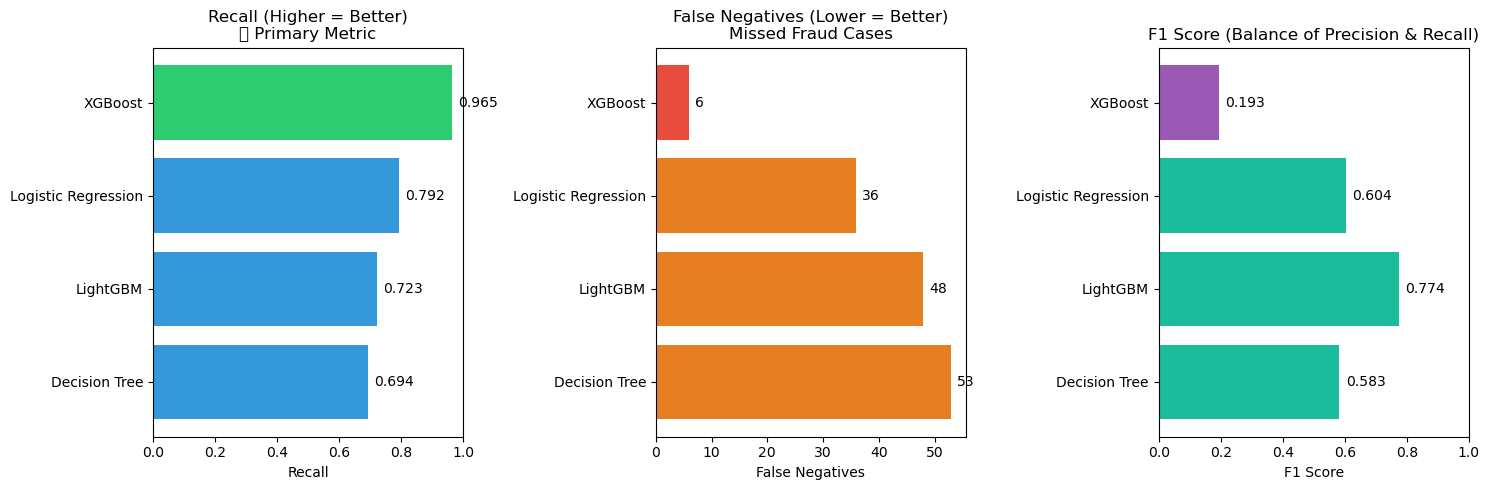

✓ Comparison chart saved to: model_comparison.png


In [132]:
# Visualize model comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sort for consistent ordering
plot_df = comparison_df.reset_index().sort_values('recall', ascending=True)

# Plot 1: Recall comparison
ax1 = axes[0]
colors = ['#2ecc71' if name == best_model_name else '#3498db' for name in plot_df['model_name']]
ax1.barh(plot_df['model_name'], plot_df['recall'], color=colors)
ax1.set_xlabel('Recall')
ax1.set_title('Recall (Higher = Better)\n⭐ Primary Metric')
ax1.set_xlim(0, 1)
for i, (name, val) in enumerate(zip(plot_df['model_name'], plot_df['recall'])):
    ax1.text(val + 0.02, i, f'{val:.3f}', va='center')

# Plot 2: False Negatives
ax2 = axes[1]
colors = ['#e74c3c' if name == best_model_name else '#e67e22' for name in plot_df['model_name']]
ax2.barh(plot_df['model_name'], plot_df['fn'], color=colors)
ax2.set_xlabel('False Negatives')
ax2.set_title('False Negatives (Lower = Better)\nMissed Fraud Cases')
for i, (name, val) in enumerate(zip(plot_df['model_name'], plot_df['fn'])):
    ax2.text(val + 1, i, f'{int(val)}', va='center')

# Plot 3: F1 Score
ax3 = axes[2]
colors = ['#9b59b6' if name == best_model_name else '#1abc9c' for name in plot_df['model_name']]
ax3.barh(plot_df['model_name'], plot_df['f1'], color=colors)
ax3.set_xlabel('F1 Score')
ax3.set_title('F1 Score (Balance of Precision & Recall)')
ax3.set_xlim(0, 1)
for i, (name, val) in enumerate(zip(plot_df['model_name'], plot_df['f1'])):
    ax3.text(val + 0.02, i, f'{val:.3f}', va='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comparison chart saved to: model_comparison.png")


In [133]:
# Save the best model and all models
import pickle

# Save the best model (highest recall)
best_model = best_models[best_model_name]

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save all trained models
with open('all_models.pkl', 'wb') as f:
    pickle.dump(best_models, f)

# Save comparison results
comparison_df.to_excel('model_comparison_results.xlsx')

print("="*60)
print("MODELS SAVED!")
print("="*60)

print(f"\n✓ Files saved:")
print(f"  - best_model.pkl ({best_model_name})")
print(f"  - all_models.pkl (all 4 trained models)")
print(f"  - model_comparison_results.xlsx")
print(f"  - model_comparison.png")

print(f"\n--- Best Model Details ---")
print(f"  Model: {best_model_name}")
print(f"  Type: {type(best_model).__name__}")
print(f"  Parameters: {best_model.get_params()}")


MODELS SAVED!

✓ Files saved:
  - best_model.pkl (XGBoost)
  - all_models.pkl (all 4 trained models)
  - model_comparison_results.xlsx
  - model_comparison.png

--- Best Model Details ---
  Model: XGBoost
  Type: XGBClassifier
  Parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 

In [134]:
# Complete deployment summary

print("="*60)
print("DEPLOYMENT READY - COMPLETE PIPELINE")
print("="*60)

print("""
For deployment, you need these files:
1. preprocessing_pipeline.pkl  - Data preprocessing
2. best_model.pkl              - Trained ML model

Usage in Flask/FastAPI:
────────────────────────────────────────────────────────────
import pickle
import pandas as pd

# Load pipeline and model
with open('preprocessing_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Process frontend input
def predict_fraud(input_data):
    '''
    input_data: dict with keys:
        title, company_profile, description, requirements, benefits,
        industry, function, department, country, state, city,
        employment_type, salary_range, required_experience, required_education,
        telecommuting, has_company_logo, has_questions
    '''
    # Convert to DataFrame
    df = pd.DataFrame([input_data])
    
    # Preprocess
    X = pipeline.transform(df)
    
    # Predict
    prediction = model.predict(X)[0]
    probability = model.predict_proba(X)[0][1]
    
    return {
        'is_fraud': bool(prediction),
        'fraud_probability': float(probability)
    }
────────────────────────────────────────────────────────────
""")

print("✅ Training complete! Ready for deployment.")


DEPLOYMENT READY - COMPLETE PIPELINE

For deployment, you need these files:
1. preprocessing_pipeline.pkl  - Data preprocessing
2. best_model.pkl              - Trained ML model

Usage in Flask/FastAPI:
────────────────────────────────────────────────────────────
import pickle
import pandas as pd

# Load pipeline and model
with open('preprocessing_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

with open('best_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Process frontend input
def predict_fraud(input_data):
    '''
    input_data: dict with keys:
        title, company_profile, description, requirements, benefits,
        industry, function, department, country, state, city,
        employment_type, salary_range, required_experience, required_education,
        telecommuting, has_company_logo, has_questions
    '''
    # Convert to DataFrame
    df = pd.DataFrame([input_data])
    
    # Preprocess
    X = pipeline.transform(df)
    
    # Predict
    prediction = mo

Exception ignored in: <function ResourceTracker.__del__ at 0x107071bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102ad9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106ea1bc0>
Traceback (most recent call last